# Gen AI Notes

## Topics
- Retrieval Methods:
    - Sparse Retrieval (BM25)
    - Dense Retrieval (Embeddings)
- Reciprocal Rank Fusion (RRF)


# Introduction Notes

- Large Language Model (LLM): A neural network trained to predict the next term of the input sequence.

- Tokenization: Breaks raw text down into smaller chunks called tokens (words, parts of words, or punctuation) before feeding them into a large language model.

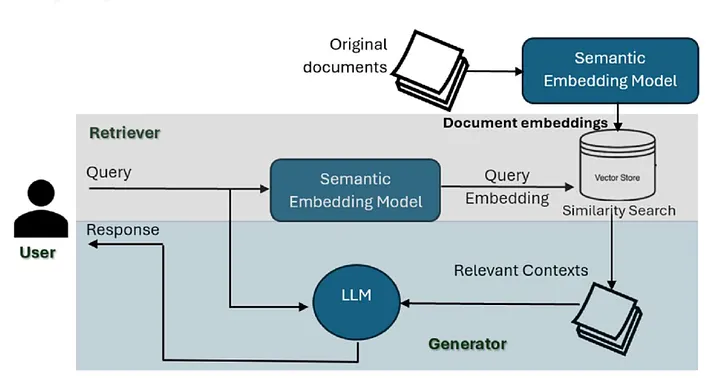

- Modern RAG implementations typically combine transformer encoders with sophisticated document collections. 
- Three phases of RAG are:
    1. Indexing Phase
        Ingestion -> Chunking -> Embedding (Encoder) -> Vector DB
    2. Retrieval Phase: When a query arrives, the system generates embeddings using the same encoder employed during indexing. It then searches the vector database to identify the most relevant chunks, typically selecting the top-k results based on similarity scores.
    3. Generation Phase: The retrieved chunks are incorporated into the prompt sent to the LLM, providing context for generating accurate responses. Advanced implementations maintain conversation history and ensure consistency across multi-turn interactions.

- Architecture Diagram:

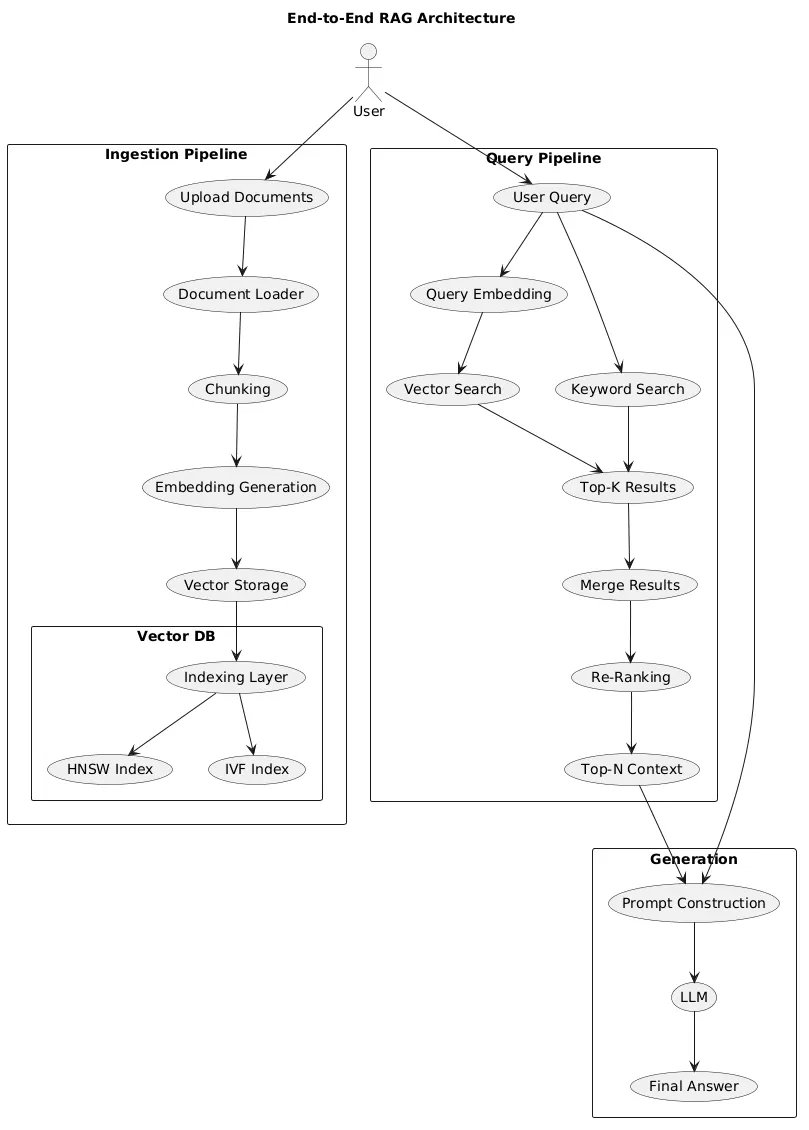
    

## Vectorization vs Embeddings

-  Vectorization: Vectorization is the process of converting tokens (can be words, pixels, counts) into numerical vectors (list of numbers).
    - Rule based methods like Bag of Words and Term-Frequency-Inverse document frequency (TF-IDF).

- Embedding: A type of vectorization produced by machine learning models that captures the semantic meaning and context of the data.
    - Map items into a continuous vector space where similar concepts sit close together.
    - Uses neural network or transformers like Word2Vec or BERT.
    - Types of Embedding model:
        - Bi-Encoders: Efficient for large-scale retrieval
        - Cross-Encoders: Precise for relevance assessment
        - Hybrid models (like ColBERT): Balancing efficiency and precision

- Every embedding is a vector but not all vectors are embeddings.

## Indexing Pipeline - Stage 0

- A RAG (Retrieval-Augmented Generation) indexing pipeline prepares and stores raw data into a searchable format so a language model can fetch accurate context later.

- This runs offline, not at query time, and it's where most production bugs actually live.

- Each record stored in the indexing layer (Vector DB or FAISS or IVF) usually consists of the following information as stored in a specific format:
    - Embedding vector
    - Chunk text
    - Metadata
- This is stored in the following manner as it is fast, simple and has low latency. Storing data in this manner facilitates multiple retrieval methods without change of index.
- Chunking Strategy: feeds both indexes. Chunk size is a real trade-off: too small and BM25 loses term co-occurrence context; too large and dense embeddings get diluted (the embedding of a 2000-token chunk is a blurry average, not a sharp semantic signature). Typical range: 256–512 tokens with 10–20% overlap.

- Indexing Layer:

- BM25 Index: keyword based ranking method used by search engines to score and sort documents by their relevance to a search query.
    - Tokenization: Raw text is split into individual words or tokens, cleaned up by lowercasing, and stripped of punctuation.
    - Term Frequency (TF): It measures how often a query word appears in a document, using a saturation limit so repeating a word endlessly stops adding huge score benefits.
    - Inverse Document Frequency (IDF): It measures how rare a word is across the whole database, giving high weight to unique words and low weight to common words like "the". 
    - Document Length Normalization: It adjusts scores so long documents do not unfairly beat short, focused documents that happen to mention your keyword

- Dense Index: turns text chunks into numerical vectors (embeddings) and organizes them to find semantic meaning quickly.
    - Critically: document embeddings are computed once, offline, and cached.
    - The Dense index (FAISS, pgvector, Vertex AI Vector Search, Pinecone) stores embeddings from a bi-encoder (e.g., text-embedding-004, bge-large).
    - Cheaper than cross-encoder as the embeddings are precomputed and ready for similarity searches.
    - The search algorithm: Approximate Nearest Neighbor (ANN)
        - ANN is an efficient algorithm technique that finds data points close to a query vector in high-dimensional spaces without scanning every single vector in the dataset.
        - Trade-off: Sacrifices absolute precision (100% recall) for massive gains in search speed and scalability.
        - Indexing: Uses pre-processed data structures to rule out irrelevant parts of the dataset instantly.
            - Common Indexing Algorithms:
                1. Hierarchial Navigable Small World (HNSW):  Builds a multi-layer proximity graph for extremely fast, high-accuracy graph traversal.
                2. Inverted File Index: Groups vectors into clustered buckets (centroids) to search only the most promising regions.
                3. Product Quantization (PQ): Compresses vectors to reduce memory footprint and speed up distance math

        - Distance Metrics: Measures of closeness
            1. Cosine Similarity: measures the angle between two vectors. This is the standard for text embeddings. Two vectors pointing in roughly the same direction are similar, regardless of their magnitude.
            2. Euclidean Distance(L2): straight-line distance between points. This is how we normally think about distance, but it breaks down when you have many dimensions and it is also sensitive to vector magnitude.
            3. Dot Product: fast to compute, works well when vectors are normalized (which makes it equivalent to cosine similarity). A normalized vector is a vector that has been scaled so that its length (magnitude) is 1, while keeping its direction the same.

- In an external hybrid search setup, the same chunks are often stored in both the vector database and a keyword search engine like Elasticsearch to facilitate their respective search process as well as indexing. This is not redundant storage but purpose-specific indexing. In production, this is often managed via a single source of truth (like a database or data lake) and synchronized to both systems through pipelines, ensuring consistency while enabling fast and accurate retrieval.

## Query Transformation - Stage 1

# Retrieval

## Types of Retrieval Methods

### Sparse Retrieval (BM25)

### Dense Retrieval (Embeddings)

## Reciprocal Rank Fusion

- Reciprocal Rank Fusion is a rank aggregation method that combines rankings from multiple sources into a single, unified ranking.

The RRF Formula

The core of RRF is captured in its formula:

RRF(d) = Σ(r ∈ R) 1 / (k + r(d))

